# Cell 0: Install necessary packages

In [4]:
!pip install --quiet diffusers transformers accelerate torch pillow pandas numpy

# Cell 1: Imports and installs

In [6]:
import os
import io
import base64
import time
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import numpy as np
import torch
from PIL import Image
from IPython.display import display, HTML
from diffusers import StableDiffusionPipeline

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Environment ready. Using Stable Diffusion v1.5. Results saved to:", RESULTS_DIR.resolve())

from transformers.utils import logging
logging.disable_progress_bar()
import os
os.environ["DISABLE_TQDM"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

Environment ready. Using Stable Diffusion v1.5. Results saved to: /content/results


# Cell 2: Configuration [EDIT FOR CUSTOMIZATION!]

In [7]:
# Number of realistic and unrealistic images to generate
x_realistic = 5
y_unrealistic = 2

# Edit this list to include the textual concepts you want to compare images against.
text_prompts = [
    "a photo of a dog",
    "an image of a cat",
    "a fluffy golden retriever running in a park",
    "a siamese cat sleeping on a couch",
    "a red sports car on a highway",
    "a portrait of a bald man in studio lighting",
    "an aerial view of a city at night",
    "a close-up of a sunflower",
    "a painting of a landscape with mountains",
    "a fantasy castle on a cliff"
]

# Realistic image generation prompts (x entries)
realistic_prompts = [
    "a high-resolution photo of a fluffy golden retriever",
    "a realistic photograph of a tabby cat sleeping",
    "a close-up photo of a dog running with tongue out",
    "a realistic portrait photo of a siamese cat",
    "a photo of a small brown dog sitting on a wooden floor"
    "a cartoon-style dragon breathing fire",
    "a futuristic city with flying cars at sunset",
    "a realistic photo of a pepperoni pizza on a wooden table"
    "a high-resolution photo of a fluffy golden retriever",
    "a realistic photograph of a tabby cat sleeping",
    "a close-up photo of a dog running with tongue out",
    "a realistic portrait photo of a siamese cat",
    "a photo of a small brown dog sitting on a wooden floor"

][:x_realistic]

# Unrealistic prompts (y entries)

unrealistic_prompts = [
    "a centaur raiding an alien outpost on Mars, cinematic scene",
    "a giant astronaut-octopus playing a piano on the Moon"
    "a dragon made of water flying over a city made of glass",
    "a two-headed cat playing chess in zero gravity"
][:y_unrealistic]

print("Configuration ready. Realistic prompts:", len(realistic_prompts), "Unrealistic prompts:", len(unrealistic_prompts))




Configuration ready. Realistic prompts: 5 Unrealistic prompts: 2


# Cell 3: Initialize Stable Diffusion + CLIP model/processor

In [8]:
from diffusers import StableDiffusionPipeline
from transformers import CLIPModel, CLIPProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    safety_checker=None,
    feature_extractor=None,
    torch_dtype=torch.float16,
    tqdm_disable=True
).to(device)

print("Stable Diffusion initialized (safety checker disabled).")

clip_model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(clip_model_name)
model = CLIPModel.from_pretrained(clip_model_name).to(device)
model.eval()

def normalize_embeddings(tensor: torch.Tensor) -> torch.Tensor:
    return tensor / tensor.norm(p=2, dim=-1, keepdim=True)

def compute_text_embeddings(texts):
    with torch.no_grad():
        inputs = processor(text=texts, images=None, return_tensors="pt", padding=True).to(device)
        text_emb = model.get_text_features(**inputs)
        text_emb = normalize_embeddings(text_emb)
    return text_emb.cpu().numpy()

def compute_image_embeddings(images):
    with torch.no_grad():
        inputs = processor(images=images, return_tensors="pt").to(device)
        img_emb = model.get_image_features(**inputs)
        img_emb = normalize_embeddings(img_emb)
    return img_emb.cpu().numpy()

print("Stable Diffusion and CLIP initialized.")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Keyword arguments {'tqdm_disable': True} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow process

Stable Diffusion initialized (safety checker disabled).
Stable Diffusion and CLIP initialized.


# Cell 4: Stable Diffusion image generator

In [9]:
# Generates and saves an image

def generate_and_save(prompt: str, idx: int, kind: str = "realistic"):
    print(f"Generating SD image for [{kind} #{idx}]: {prompt}")

    result = pipe(prompt, num_inference_steps=28, guidance_scale=7.5)
    img = result.images[0]

    out_path = RESULTS_DIR / f"{kind}_{idx}_cand_0.png"
    img.save(out_path)

    return out_path, [out_path]

def generate_batch(prompts: List[str], kind: str):
    pil_images = []
    representative_paths = []
    all_candidate_paths = []

    for i, p in enumerate(prompts):
        rep_path, cand_paths = generate_and_save(p, i, kind)
        representative_paths.append(rep_path)
        all_candidate_paths.append(cand_paths)
        pil_images.append(Image.open(rep_path).convert("RGB"))

    return pil_images, representative_paths, all_candidate_paths

# Cell 5: Generate images

In [11]:
print("Starting generation of realistic images...")
real_images_pil, real_repr_paths, real_all_paths = generate_batch(realistic_prompts, kind="realistic")
print("Realistic generation done.\n")

print("Starting generation of unrealistic images...")
unreal_images_pil, unreal_repr_paths, unreal_all_paths = generate_batch(unrealistic_prompts, kind="unrealistic")
print("Unrealistic generation done.\n")

all_images_pil = real_images_pil + unreal_images_pil
all_prompts_used = realistic_prompts + unrealistic_prompts
all_repr_paths = real_repr_paths + unreal_repr_paths
all_candidate_paths = real_all_paths + unreal_all_paths

print(f"Total images generated (representatives): {len(all_images_pil)}")

Starting generation of realistic images...
Generating SD image for [realistic #0]: a high-resolution photo of a fluffy golden retriever


  0%|          | 0/28 [00:00<?, ?it/s]

Generating SD image for [realistic #1]: a realistic photograph of a tabby cat sleeping


  0%|          | 0/28 [00:00<?, ?it/s]

Generating SD image for [realistic #2]: a close-up photo of a dog running with tongue out


...

Realistic generation done.

Starting generation of unrealistic images...
Generating SD image for [unrealistic #0]: a centaur raiding an alien outpost on Mars, cinematic scene


  0%|          | 0/28 [00:00<?, ?it/s]

Generating SD image for [unrealistic #1]: a giant astronaut-octopus playing a piano on the Moona dragon made of water flying over a city made of glass


  0%|          | 0/28 [00:00<?, ?it/s]

Unrealistic generation done.

Total images generated (representatives): 7


# Cell 6: Compute embeddings

In [18]:
print("Computing text embeddings for text_prompts (embedding bank)...")
text_embeddings = compute_text_embeddings(text_prompts)
print("Text embeddings shape:", text_embeddings.shape)

print("Computing image embeddings for generated images...")
image_embeddings = compute_image_embeddings(all_images_pil)
print("Image embeddings shape:", image_embeddings.shape)

Computing text embeddings for text_prompts (embedding bank)...
Text embeddings shape: (10, 512)
Computing image embeddings for generated images...
Image embeddings shape: (7, 512)


# Cell 7: Similarity computation (cosine similarity) and results table

In [19]:
def cosine_similarity_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    # Note they are pre-normalized so we ignore that and just do dot prod.
    return np.dot(A, B.T)

# Compute similarities: images x texts
sims = cosine_similarity_matrix(image_embeddings, text_embeddings)

# For each image, find top-k matching text entries and report scores
top_k = 3
rows = []
for i, img_path in enumerate(all_repr_paths):
    sim_row = sims[i]
    top_idx = np.argsort(-sim_row)[:top_k]
    top_texts = [text_prompts[j] for j in top_idx]
    top_scores = [float(sim_row[j]) for j in top_idx]

    row = {
        "image_index": i,
        "image_path": str(img_path),
        "image_prompt_used": all_prompts_used[i],
        "top1_text": top_texts[0],
        "top1_score": top_scores[0],
        "top2_text": top_texts[1] if len(top_texts) > 1 else "",
        "top2_score": top_scores[1] if len(top_scores) > 1 else None,
        "top3_text": top_texts[2] if len(top_texts) > 2 else "",
        "top3_score": top_scores[2] if len(top_scores) > 2 else None,
        "is_realistic": i < len(real_images_pil)
    }
    rows.append(row)

df = pd.DataFrame(rows)
csv_path = RESULTS_DIR / "similarity_results.csv"
df.to_csv(csv_path, index=False)
print("Similarity results saved to:", csv_path)

np.save(RESULTS_DIR / "similarity_matrix.npy", sims)

Similarity results saved to: results/similarity_results.csv


# Cell 8: Show summary statistics comparing realistic vs unrealistic

In [20]:
real_count = len(real_images_pil)
unreal_count = len(unreal_images_pil)

# Average top1 similarity for realistic vs unrealistic
top1_scores = df["top1_score"].astype(float)
avg_real_top1 = top1_scores[df["is_realistic"]].mean()
avg_unreal_top1 = top1_scores[~df["is_realistic"]].mean()

summary_text = f"""
Summary:
- realistic images (n={real_count}) average top-1 similarity to text bank = {avg_real_top1:.4f}
- unrealistic images (n={unreal_count}) average top-1 similarity to text bank = {avg_unreal_top1:.4f}
Saved CSV: {csv_path}
"""

print(summary_text)


Summary:
- realistic images (n=5) average top-1 similarity to text bank = 0.2858
- unrealistic images (n=2) average top-1 similarity to text bank = 0.1914
Saved CSV: results/similarity_results.csv



In [21]:
# analysis: deeper look at CLIP top-1 similarities

import numpy as np
import pandas as pd

# Make sure top1_score is numeric
df["top1_score"] = df["top1_score"].astype(float)

real_mask = df["is_realistic"]
unreal_mask = ~df["is_realistic"]

real_scores = df.loc[real_mask, "top1_score"]
unreal_scores = df.loc[unreal_mask, "top1_score"]

print("=== Top-1 similarity stats ===\n")

print("Realistic images:")
print(f"  count : {real_scores.count()}")
print(f"  mean  : {real_scores.mean():.4f}")
print(f"  std   : {real_scores.std(ddof=1):.4f}")
print(f"  min   : {real_scores.min():.4f}")
print(f"  25%   : {real_scores.quantile(0.25):.4f}")
print(f"  50%   : {real_scores.median():.4f}")
print(f"  75%   : {real_scores.quantile(0.75):.4f}")
print(f"  max   : {real_scores.max():.4f}\n")

print("Unrealistic images:")
print(f"  count : {unreal_scores.count()}")
print(f"  mean  : {unreal_scores.mean():.4f}")
print(f"  std   : {unreal_scores.std(ddof=1):.4f}")
print(f"  min   : {unreal_scores.min():.4f}")
print(f"  25%   : {unreal_scores.quantile(0.25):.4f}")
print(f"  50%   : {unreal_scores.median():.4f}")
print(f"  75%   : {unreal_scores.quantile(0.75):.4f}")
print(f"  max   : {unreal_scores.max():.4f}\n")

# Difference in means + rough effect size
mean_diff = real_scores.mean() - unreal_scores.mean()
pooled_var = (real_scores.var(ddof=1) + unreal_scores.var(ddof=1)) / 2
pooled_std = float(np.sqrt(pooled_var)) if pooled_var > 0 else np.nan
cohen_d = mean_diff / pooled_std if pooled_std > 0 else np.nan

print("=== Comparison ===")
print(f"Mean difference (real - unreal): {mean_diff:.4f}")
print(f"Approx. effect size (Cohen's d): {cohen_d:.3f}\n")

# Which text prompts show up most often as top-1 for each group
print("=== Most common top-1 text matches (realistic images) ===")
print(df.loc[real_mask, "top1_text"].value_counts().head(10), "\n")

print("=== Most common top-1 text matches (unrealistic images) ===")
print(df.loc[unreal_mask, "top1_text"].value_counts().head(10))


=== Top-1 similarity stats ===

Realistic images:
  count : 5
  mean  : 0.2858
  std   : 0.0143
  min   : 0.2761
  25%   : 0.2793
  50%   : 0.2810
  75%   : 0.2817
  max   : 0.3110

Unrealistic images:
  count : 2
  mean  : 0.1914
  std   : 0.0011
  min   : 0.1906
  25%   : 0.1910
  50%   : 0.1914
  75%   : 0.1918
  max   : 0.1921

=== Comparison ===
Mean difference (real - unreal): 0.0944
Approx. effect size (Cohen's d): 9.345

=== Most common top-1 text matches (realistic images) ===
top1_text
a fluffy golden retriever running in a park    2
an image of a cat                              2
a photo of a dog                               1
Name: count, dtype: int64 

=== Most common top-1 text matches (unrealistic images) ===
top1_text
a painting of a landscape with mountains    1
an image of a cat                           1
Name: count, dtype: int64


# Cell 9: Display images with their top matches

Image #0 | generated prompt: a high-resolution photo of a fluffy golden retriever | top1: [a fluffy golden retriever running in a park] (0.3110)


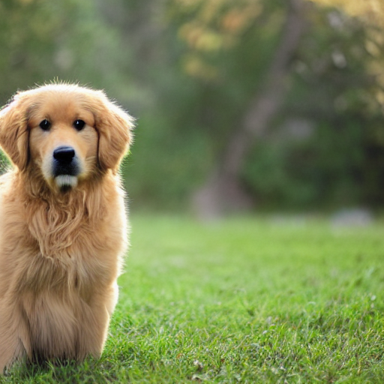

Top 3 matches:
  1) a fluffy golden retriever running in a park (0.3110)
  2) a photo of a dog (0.2760)
  3) an image of a cat (0.2118)


Image #1 | generated prompt: a realistic photograph of a tabby cat sleeping | top1: [an image of a cat] (0.2793)


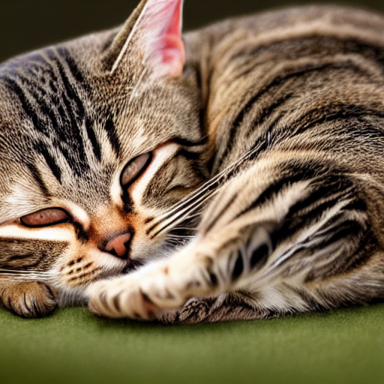

Top 3 matches:
  1) an image of a cat (0.2793)
  2) a siamese cat sleeping on a couch (0.2555)
  3) a photo of a dog (0.2205)


Image #2 | generated prompt: a close-up photo of a dog running with tongue out | top1: [a fluffy golden retriever running in a park] (0.2817)


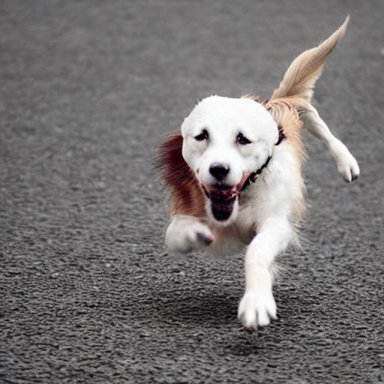

Top 3 matches:
  1) a fluffy golden retriever running in a park (0.2817)
  2) a photo of a dog (0.2556)
  3) an image of a cat (0.2053)


Image #3 | generated prompt: a realistic portrait photo of a siamese cat | top1: [an image of a cat] (0.2761)


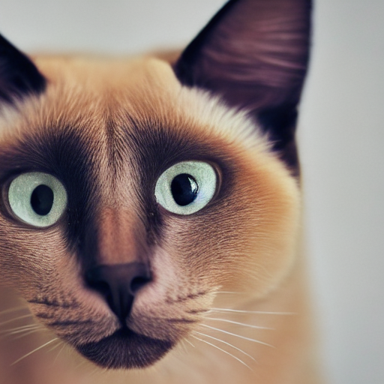

Top 3 matches:
  1) an image of a cat (0.2761)
  2) a siamese cat sleeping on a couch (0.2411)
  3) a photo of a dog (0.2242)


Image #4 | generated prompt: a photo of a small brown dog sitting on a wooden floora cartoon-style dragon breathing fire | top1: [a photo of a dog] (0.2810)


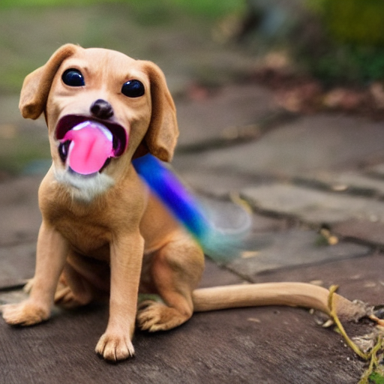

Top 3 matches:
  1) a photo of a dog (0.2810)
  2) an image of a cat (0.2314)
  3) a fluffy golden retriever running in a park (0.2247)


Image #5 | generated prompt: a centaur raiding an alien outpost on Mars, cinematic scene | top1: [a painting of a landscape with mountains] (0.1906)


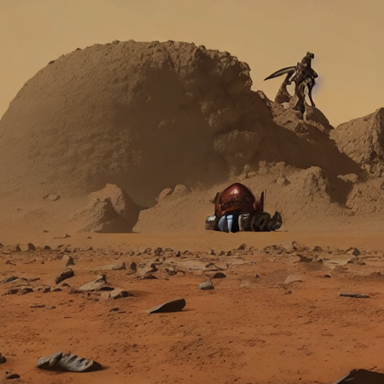

Top 3 matches:
  1) a painting of a landscape with mountains (0.1906)
  2) an image of a cat (0.1893)
  3) a fantasy castle on a cliff (0.1891)


Image #6 | generated prompt: a giant astronaut-octopus playing a piano on the Moona dragon made of water flying over a city made of glass | top1: [an image of a cat] (0.1921)


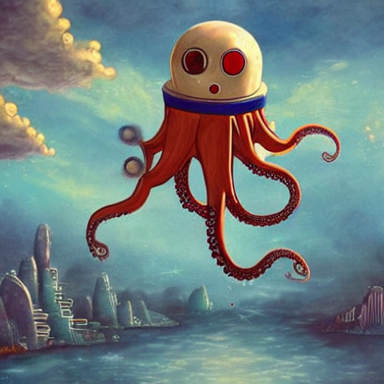

Top 3 matches:
  1) an image of a cat (0.1921)
  2) a photo of a dog (0.1825)
  3) a portrait of a bald man in studio lighting (0.1724)


Full similarity results table (saved to CSV):


image_index,image_path,image_prompt_used,top1_text,top1_score,top2_text,top2_score,top3_text,top3_score,is_realistic
0,results/realistic_0_cand_0.png,a high-resolution photo of a fluffy golden retriever,a fluffy golden retriever running in a park,0.311011,a photo of a dog,0.275989,an image of a cat,0.211831,True
1,results/realistic_1_cand_0.png,a realistic photograph of a tabby cat sleeping,an image of a cat,0.279287,a siamese cat sleeping on a couch,0.255505,a photo of a dog,0.220546,True
2,results/realistic_2_cand_0.png,a close-up photo of a dog running with tongue out,a fluffy golden retriever running in a park,0.281697,a photo of a dog,0.255580,an image of a cat,0.205282,True
3,results/realistic_3_cand_0.png,a realistic portrait photo of a siamese cat,an image of a cat,0.276098,a siamese cat sleeping on a couch,0.241117,a photo of a dog,0.224151,True
4,results/realistic_4_cand_0.png,a photo of a small brown dog sitting on a wooden floora cartoon-style dragon breathing fire,a photo of a dog,0.280973,an image of a cat,0.231355,a fluffy golden retriever running in a park,0.224743,True
5,results/unrealistic_0_cand_0.png,"a centaur raiding an alien outpost on Mars, cinematic scene",a painting of a landscape with mountains,0.190604,an image of a cat,0.189295,a fantasy castle on a cliff,0.189088,False
6,results/unrealistic_1_cand_0.png,a giant astronaut-octopus playing a piano on the Moona dragon made of water flying over a city made of glass,an image of a cat,0.192148,a photo of a dog,0.182489,a portrait of a bald man in studio lighting,0.172443,False


In [22]:
from IPython.display import Image as IPyImage, display_markdown

def display_results_table(df: pd.DataFrame):\
    display(HTML(df.to_html(index=False)))

# Show each images top 3 text descriptions
for idx, row in df.iterrows():
    img_p = row["image_path"]
    caption = f"Image #{row['image_index']} | generated prompt: {row['image_prompt_used']} | top1: [{row['top1_text']}] ({row['top1_score']:.4f})"
    print("="*80)
    print(caption)

    display(Image.open(img_p).resize((384, 384)))

    print("Top 3 matches:")
    print("  1)", row["top1_text"], f"({row['top1_score']:.4f})")
    print("  2)", row["top2_text"], f"({row['top2_score']:.4f})")
    print("  3)", row["top3_text"], f"({row['top3_score']:.4f})")
    print("\n")

print("Full similarity results table (saved to CSV):")
display_results_table(df)

# Cell 10: Save a report summarizing results

In [23]:
report_md = f"# Linking Images and Text - Results\n\n"
report_md += f"Generated {len(all_images_pil)} representative images: {len(real_images_pil)} realistic, {len(unreal_images_pil)} unrealistic.\n\n"
report_md += "## Average top-1 similarities\n\n"
report_md += f"- realistic images average top1: **{avg_real_top1:.4f}**\n"
report_md += f"- unrealistic images average top1: **{avg_unreal_top1:.4f}**\n\n"
report_md += "## Files\n\n"

for p in sorted(RESULTS_DIR.glob("*")):
    report_md += f"- {p.name}\n"

(report_path := RESULTS_DIR / "REPORT.md").write_text(report_md)
print("Report written to:", report_path)
print("\nDone. You can download the 'results/' directory or push it to GitHub. The CSV and images are standard files and should be visible on GitHub when uploaded.")

Report written to: results/REPORT.md

Done. You can download the 'results/' directory or push it to GitHub. The CSV and images are standard files and should be visible on GitHub when uploaded.


In [24]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os
import shutil

# Where your results are currently
src_results = "/content/results"

# Where in Drive you want to save them
# This will create: MyDrive/AI_Projects/LinkingImgsAndTxt/results_run1
drive_root = "/content/drive/MyDrive"
project_folder = os.path.join(drive_root, "AI_Projects", "LinkingImgsAndTxt")
save_folder = os.path.join(project_folder, "results_run1")

# Make sure the parent folder exists
os.makedirs(project_folder, exist_ok=True)

# Copy the entire results/ directory into Drive
shutil.copytree(src_results, save_folder, dirs_exist_ok=True)

print(f"Copied results to: {save_folder}")


Copied results to: /content/drive/MyDrive/AI_Projects/LinkingImgsAndTxt/results_run1
